In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from brian2 import *
import functions as fc

In [3]:
simtime1 = 1*10**3 * ms

In [4]:
data_a = np.load('analysis_a.npz', allow_pickle=True)

In [5]:
SpikeMon_t = data_a['SpikeMon_t'] 
SpikeMon_i = data_a['SpikeMon_i'] 
RateMonE_t = data_a['RateMonE_t'] 
RateMonE_rate = data_a['RateMonE_rate'] 
SpikeTrains = data_a['SpikeTrainE'].item()
Current_t = data_a['Current_t'] 
Current_inh = data_a['Current_inh']
Current_exc = data_a['Current_exc']
SynMon_t = data_a['SynMon_t']
SynMon_w = data_a['SynMon_w']

In [6]:
cv_dist_E = fc.get_isi_cv(N=800, spike_trains=SpikeTrains, t_min=0*ms, t_max=1000*ms)
mean_cv_E = np.mean(cv_dist_E)

In [7]:
spike_corr = fc.get_spike_correlations(spike_times=SpikeTrains, t_min=0, t_max=simtime1/ms)
mean_corr = np.nanmean(spike_corr)

In [8]:
from matplotlib.gridspec import GridSpec
import plot_config

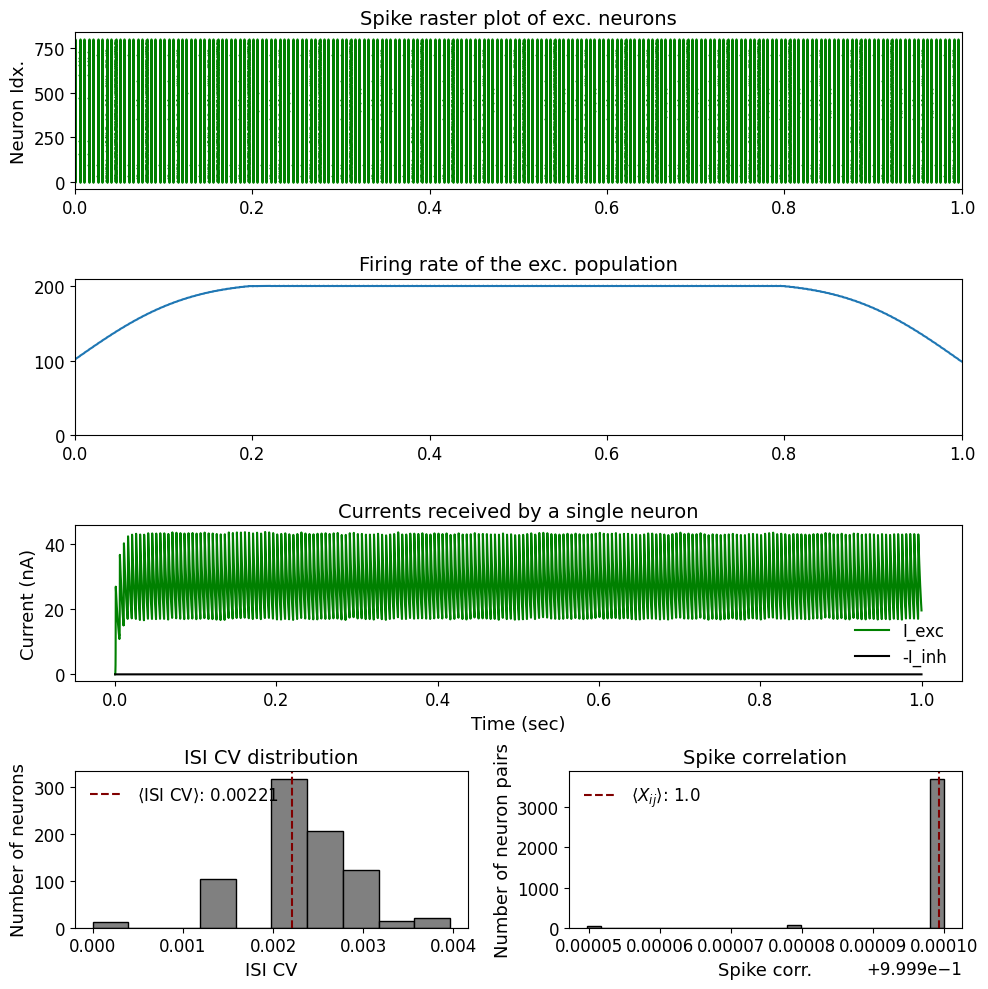

In [13]:
fig = plt.figure(figsize=(10, 10))
gs = GridSpec(4, 2, figure=fig, height_ratios=[1, 1, 1, 1])  

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(SpikeMon_t, SpikeMon_i, '.g', ms=1)
ax1.set_ylabel('Neuron Idx.')
ax1.set_title('Spike raster plot of exc. neurons')
ax1.set_xlim(0, simtime1/second)

ax2 = fig.add_subplot(gs[1, :])
ax2.plot(RateMonE_t, RateMonE_rate)
ax2.set_ylim([0, 210])
ax2.set_title('Firing rate of the exc. population')
ax2.set_xlim(0, simtime1/second)

# ax3 = fig.add_subplot(gs[2, :])
# ax3.plot(SynMon_t, SynMon_w)
# ax3.set_ylabel('$w^{EI}$ (a.u.)')
# ax3.set_title('Evolution of inh$\\rightarrow$exc. weigths')

ax4 = fig.add_subplot(gs[2, :])
ax4.plot(Current_t, Current_exc[0], color='green', label='I_exc')
ax4.plot(Current_t , Current_inh[0], color='black', label='-I_inh')
ax4.set_title('Currents received by a single neuron')
ax4.set_xlabel('Time (sec)')
ax4.set_ylabel('Current (nA)')
ax4.legend(frameon=False, loc='lower right')

ax5 = fig.add_subplot(gs[3, 0])
ax5.hist(cv_dist_E, bins=10, color='grey', edgecolor='black', alpha=1)
ax5.axvline(mean_cv_E, color='maroon', ls='--', label=f'$\\langle \\text{{ISI CV}} \\rangle$: {np.round(mean_cv_E, 5)}')
ax5.axhline(0, color='k', lw=0.8)
ax5.set_xlabel('ISI CV')
ax5.set_ylabel('Number of neurons')
ax5.set_title('ISI CV distribution')
ax5.legend(frameon=False)
ax5.set_xticks([0, 0.001, 0.002, 0.003, 0.004])

ax6 = fig.add_subplot(gs[3, 1])
ax6.hist(spike_corr, bins=25, color='grey', edgecolor='black', alpha=1)
ax6.axvline(mean_corr, color='maroon', ls='--', label=f'$\\langle X_{{ij}} \\rangle$: {np.round(mean_corr, 3)}')
ax6.axhline(0, color='k', lw=0.8)
ax6.set_xlabel('Spike corr.')
ax6.set_ylabel('Number of neuron pairs')
ax6.legend(frameon=False)
ax6.set_title('Spike correlation')
ax6.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.savefig('./Plots/fig_1.png', format='png', dpi=300, bbox_inches="tight")
plt.savefig('./Plots/fig_1.pdf', format='pdf', dpi=300, bbox_inches="tight")
plt.show()